In [16]:
'''
This script takes a collection of images as input, then uses feature detection to 
track the object's motion between frames. By tracking the features, and having the 
knowledge of how much the object rotated, we can perform a 3D reconstruction of the
object.

To get SURF, make sure to run:
pip install opencv-contrib-python
'''

#%pip install ipympl

#%matplotlib widget
#%matplotlib notebook
#%matplotlib ipympl

# Imports
import os
import sys
import time
import copy
import glob
import math
from math import pi, sqrt
import pickle

import numpy as np
import cv2 as cv
import pandas as pd
import pyvista as pv
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pylab as plt

#pv.set_jupyter_backend('trame')


# Settings
imageFolderPath = 'white_crystal_no_supports'
#imageFolderPath = 'small_white_crystal_no_supports'
resolution = np.array([5328, 4608])
scaleFactor_default = (1/8)
zAxisStepSize = 5    # the resolution in the z-axis of the 3D reconstruction (1 is the same resolution as x/y)

calibrationFilePath = './cal_images2/Camera_Calibration_%0.3f.pickle' % scaleFactor_default


#-------------------------------------------------------------------------------
#                                   show_image
#-------------------------------------------------------------------------------
def show_image(title, opencvImage):
    
    plt.figure()
    # OpenCV stores images in BGR order instead of RGB, so convert
    plt.imshow(cv.cvtColor(opencvImage, cv.COLOR_BGR2RGB))
    plt.title(title)

    return


#-------------------------------------------------------------------------------
#                                   resize_image
#-------------------------------------------------------------------------------
def resize_image(img, newResolution=(64,64)):
    width = newResolution[0]
    height = newResolution[1]
    resized = cv.resize(img.copy(), (int(width), int(height)), interpolation=cv.INTER_AREA)
    return resized


#-------------------------------------------------------------------------------
#                               load_image
#-------------------------------------------------------------------------------
def load_image(degrees=0, scaleFactor=scaleFactor_default, folder=imageFolderPath):

    filePath = '%s/crystal_%04d.jpg' % (folder, degrees)
    img = None

    if os.path.exists(filePath):

        print(f'Loading "{filePath}"...')
        img = cv.imread(filePath)

        # Check if image was actually loaded (catches corrupted files)
        if img is None:
            print(f'ERROR: Failed to read image (corrupted?): {filePath}')
            return None

        h, w, _ = img.shape
        newRes = (w * scaleFactor, h * scaleFactor)
        img = resize_image(img, newRes)

    else:
        print(f'ERROR: Image file not found ({filePath})')

    return img

# Load Images

Loading "white_crystal_no_supports/crystal_0045.jpg"...
Image Size: 666 x 576


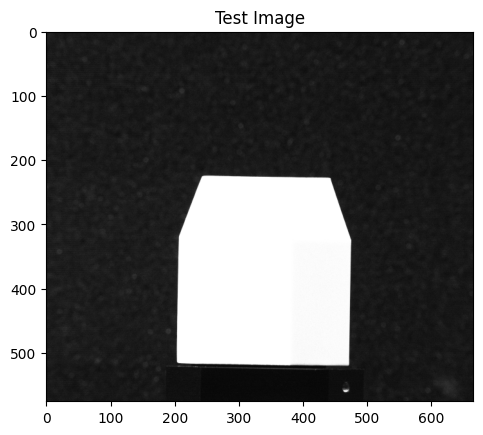

In [17]:
# Load the image
img = load_image(45)
h,w,_ = img.shape
print(f'Image Size: {w} x {h}')

# Show it
show_image('Test Image', img)

# Make the Mask (Matte)

In [18]:
def make_mask(img, threshold=50, maxVal=255):

    # Convert to grayscale
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # Apply the threshold
    #ret,maskImg = cv.threshold(gray, threshold, maxVal, cv.THRESH_BINARY)

    # Apply a blur to the image
    blur = cv.GaussianBlur(gray, (11,11), 0)

    # https://docs.opencv.org/4.x/d3/db4/tutorial_py_watershed.html

    # Perform thresholding
    ret, thresh = cv.threshold(blur, 0, 2**8, cv.THRESH_BINARY+cv.THRESH_OTSU)  # Otsu algorithm for optimal threshold value
    #ret, thresh = cv.threshold(img, 0, 2**nBits_av1, cv.THRESH_BINARY+cv.THRESH_OTSU)  # Otsu algorithm for optimal threshold value
    #ret, thresh = cv.threshold(img, 0, 2**nBits_av1, cv.THRESH_BINARY+cv.THRESH_TRIANGLE)  # trangle algorithm for optimal threshold value
    #thresh = cv.adaptiveThreshold(img, 2**nBits_av1, cv.BORDER_REPLICATE, cv.THRESH_BINARY_INV, blockSize=21, C=0)

    #thresh = cv.adaptiveThreshold(img, 2**nBits_av1, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY_INV, blockSize=11, C=0)
    #thresh = cv.adaptiveThreshold(img, 2**nBits_av1, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY_INV, blockSize=11, C=0)

    return thresh

Image Size: 666 x 576


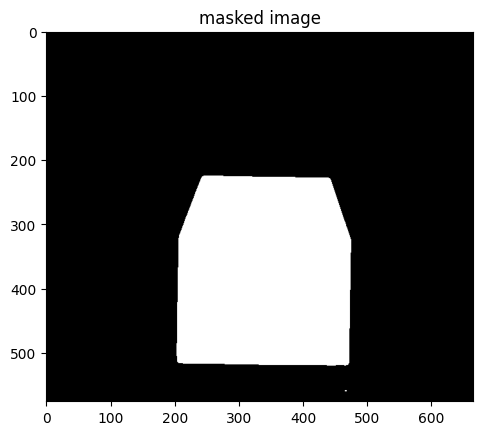

In [19]:
maskImg = make_mask(img)
show_image('masked image', maskImg)

h,w,_ = img.shape
print(f'Image Size: {w} x {h}')

# Use contour detection (boundary tracing) to get the perimeter

In [20]:
def get_boundary(img, showContours=True, plotTitle='contours'):
    # https://learnopencv.com/contour-detection-using-opencv-python-c/
    # https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0
    # https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga17ed9f5d79ae97bd4c7cf18403e1689a

    # TODO:  the findContours algorithm expects a white object on a black background...  May need to pre-proces for the generic / transparent cases.

    # detect the contours on the binary image using cv2.CHAIN_APPROX_NONE
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_NONE)
    contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_EXTERNAL, method=cv.CHAIN_APPROX_NONE)
    
    # TODO: Try the simple algorithm, then fit lines in between the points to approximate...
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_SIMPLE)

    # This one is filtered... https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga4303f45752694956374734a03c54d5ff
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_TC89_L1)

    # This one is also filtered... https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#ga4303f45752694956374734a03c54d5ff
    #contours, hierarchy = cv.findContours(image=img, mode=cv.RETR_TREE, method=cv.CHAIN_APPROX_TC89_KCOS)



    # Find the biggest contour
    biggestIndex = None
    biggestSize = 0
    for i,c in enumerate(contours):
        if len(c) > biggestSize:
            biggestSize = len(c)
            biggestIndex = i

    contours = contours[biggestIndex]

    x = contours[:,0,0]
    y = contours[:,0,1]

    if showContours == True:
        # draw contours on the original image
        #image_copy = img.copy()
        #cv.drawContours(image=image_copy, contours=contours, contourIdx=-1, color=(0, 255, 0), thickness=2, lineType=cv.LINE_AA)
        #show_image('contours', image_copy)
        show_image(plotTitle, img)
        plt.plot(x, y, 'r.')


    h,w = img.shape


    # TODO:  This really should take into account the camera viewing angle. The big assumption here (which is OK in this case) is 
    #        that the center of the camera/lens is aligned with the center of the rotational stage.

    # center the x axis about 0
    x = np.array(x - w/2, dtype=int)    # This needs to be the center of rotation...
    
    # Invert the y axis
    y = h - y

    c = np.matrix((x, y)).T  # return x/y pairs

    # Remove redundant points
    #c = np.unique(c, axis=0)

    if showContours == True:
        fig2 = plt.figure()
        plt.plot(c[:,0], c[:,1], '.')
        plt.grid(True)
        plt.axis('image')
        plt.title('Contour Points')

    return np.matrix(c)

xDelta =np.int64(271) (57.994 mm)
yDelta =np.int64(295) (63.129999999999995 mm)


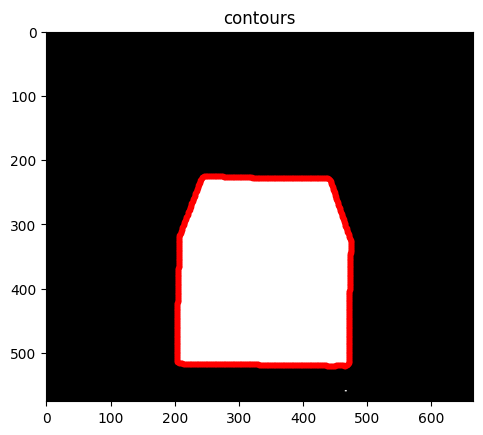

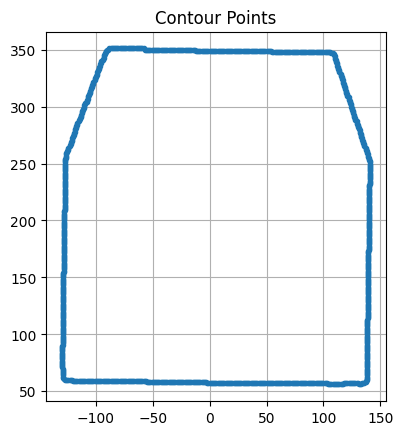

In [21]:
contours = get_boundary(maskImg, showContours=True)

x = contours[:,0]
y = contours[:,1]
xDelta = np.max(x) - np.min(x)
yDelta = np.max(y) - np.min(y)

print(f'{xDelta =} ({xDelta*0.214} mm)')
print(f'{yDelta =} ({yDelta*0.214} mm)')

# Rotate 3D

In [22]:
def rotate_3d(coords,angle=0,axis=[0,1,0]):

    theta = angle * np.pi / 180.

    Rx = np.matrix([[1,                 0,                  0],
                    [0,                 np.cos(theta),      -np.sin(theta)],
                    [0,                 np.sin(theta),      np.cos(theta)]
                  ])

    Ry = np.matrix([[np.cos(theta),     0,                  np.sin(theta)],
                    [0,                 1,                  0],
                    [-np.sin(theta),    0,                  np.cos(theta)]
                  ])

    Rz = np.matrix([[np.cos(theta),     -np.sin(theta),     0],
                    [np.sin(theta),     np.cos(theta),      0],
                    [0,                 0,                  1]
                  ])

    # TODO: Support rotation along other axes...
    rotationMatrix = Ry


    if type(coords) == type([]):
      
      coords_rotated = []

      if len(coords) > 0:
        for c in coords:
          if np.shape(c)[1] > 0:
            cr = rotationMatrix * c.T
            coords_rotated.append(cr.T)

    else:
      coords_rotated = rotationMatrix * coords.T
      coords_rotated = coords_rotated.T

    return coords_rotated

In [23]:
def contour_to_3d(contour2d):

    # Get the size of the contours (number of points)
    numPts,_ = np.shape(contour2d)

    # Add a zero vector to the contour matrix
    zVect = np.matrix(np.zeros((numPts, 1)))
    #contours_3d = np.hstack((contour2d[:,0], zVect, contour2d[:,1]))
    contours_3d = np.hstack((contour2d[:,0], contour2d[:,1], zVect))

    return contours_3d

# Create a 3D version of the contour through multiple depth planes

In [24]:
def contour_to_3d_with_depth(contour2d, zMin=-640, zMax=640, zStep=1):

    # Get the size of the contours (number of points)
    numPts,_ = np.shape(contour2d)

    # Add a zero vector to the contour matrix
    zVect = np.matrix(np.zeros((numPts, 1)))
    
    # Create the 3d vector
    contours_3d = np.hstack((contour2d[:,0], contour2d[:,1], zVect))

    # Define the z coordinates
    #z = np.matrix(np.arange(zMin, zMax+zStep, zStep)).T
    z = np.arange(zMin, zMax+zStep, zStep)

    # Figure out how many elements we have in the z direction
    Nz = len(z)

    # Figure out how many elements we have in the contour
    Nxy = np.shape(contour2d)[0]

    # Replicate this stack
    contours_3d_deep = np.tile(contours_3d, (Nz, 1))

    # Add the z coordinates
    i = 0
    for iz in range(0, Nz):
        for ixy in range(0, Nxy):
            contours_3d_deep[i,2] = z[iz]
            i += 1

    return contours_3d_deep

Loading "white_crystal_no_supports/crystal_0000.jpg"...


(0.0, 640.0)

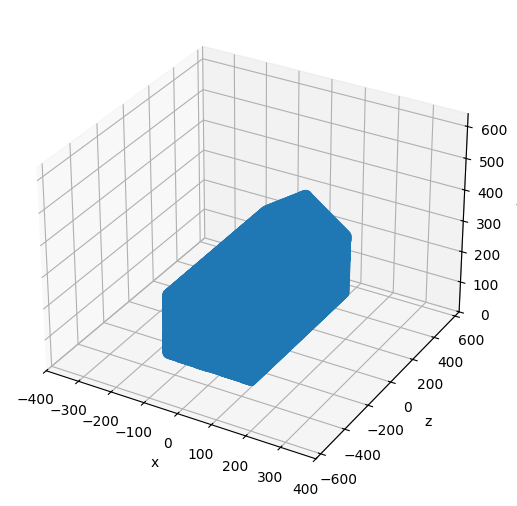

In [25]:
#print(contour_to_3d_with_depth(np.matrix([[0,0],[0,1],[0,2]]), -2, 2, 1))

# Load a test contour
img = load_image(0)
maskImg = make_mask(img)
contours = get_boundary(maskImg, showContours=False)
contours3d_deep = contour_to_3d_with_depth(contours, zMin=-400, zMax=400, zStep=10)


# Plot the two contours to check alignment
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.scatter(contours3d_deep[:,0], contours3d_deep[:,2], contours3d_deep[:,1], 'b.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

ax.set_xlim3d(-400, 400)
ax.set_ylim3d(-640, 640)
ax.set_zlim3d(0,640)

# Test Contours

Loading "white_crystal_no_supports/crystal_0110.jpg"...


(np.float64(-136.2), np.float64(154.2), np.float64(41.2), np.float64(366.8))

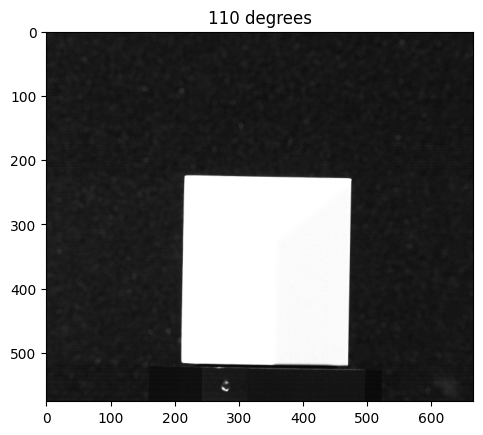

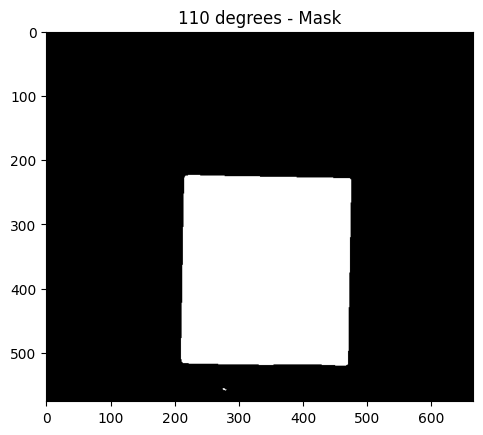

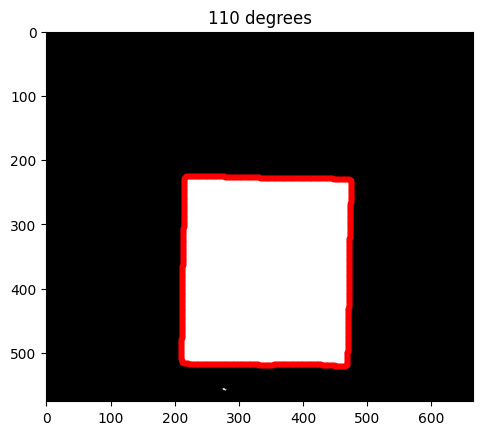

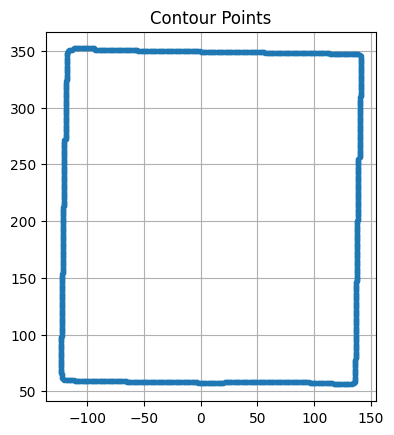

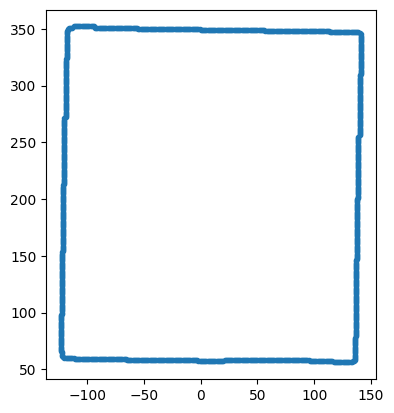

In [26]:

angle = 110

# Load the image
img = load_image(angle)

# Display the image
show_image(f'{angle} degrees', img)

# Create the mask / matte
maskImg = make_mask(img)

# Display the image
show_image(f'{angle} degrees - Mask', maskImg)

# Load the contours
contours = get_boundary(maskImg, showContours=True, plotTitle=f'{angle} degrees')


fig = plt.figure()
plt.plot(contours[:,0], contours[:,1], '.')
plt.axis('image')

# Michelangelo

In [27]:
def michelangelo(contour, block):
    '''
    Carve out the parts that aren't David. 
    
    Each rotated view carves out a section of the "block". In this way, we remove
    the parts that aren't associated with the object.

    NOTE: this carving operation is done from the camera's perspective (from the 
          camera viewing angle). To do this in a less constrained environment, the
          camera angle (relative to the object) needs to be determined.
    '''

    newBlock = []

    for pt in block:
        # determine if a point is inside, or outside, of the polygon formed by the contour vector
        x = pt[0, 0]
        y = pt[0, 1]
        z = pt[0, 2]
        #pt = (x, z)
        pt = (x, y)

        # https://docs.opencv.org/3.4.5/d3/dc0/group__imgproc__shape.html#ga1a539e8db2135af2566103705d7a5722
        result = cv.pointPolygonTest(contour, pt, measureDist=False)

        if result >= 0:
            newBlock.append((x, y, z))


    newBlock = np.matrix(newBlock)
    
    return newBlock

# Load the camera calibration (for pixel -> mm scaling)
https://docs.google.com/spreadsheets/d/1HlIQD8qF7d1AKRB1dQvAReDSbLFnypIe2-no22aY2lQ/edit#gid=0

In [28]:
def scale_coords(block, calibrationFilePath):

    # Load the camera calibration
    if os.path.exists(calibrationFilePath) == False:
        raise Exception(f'ERROR: could not find calibration file ({calibrationFilePath})')

    with open(calibrationFilePath, 'rb') as f:
        data = pickle.load(f)

    scaling = data['scalingFactor']   # mm / pixel

    scaling *= 0.88   # not from calibration directly, so this is suspicious.  This was from reconciling the 3D-printed model.

    print(f'Applying a scaling factor of {scaling} to the block...')

    # Apply the scaling factor (pixel coordinates --> real world (mm) coordinates)
    #block = float(scaling) * np.array(block, dtype=float)
    block *= scaling

    # Convert back to an int32
    #block = np.array(block, dtype=np.int32)

    return block

# Initialize the Block (deep bunnies)

In [29]:
w = int(resolution[0] * scaleFactor_default)
h = int(resolution[1] * scaleFactor_default)

#--------------------------------------------------
#  Initialize the block
#--------------------------------------------------
zMin = -w    # check these values
zMax = w     # check these values
zStep = zAxisStepSize
block = None

angleStep = 5
angleMax = 360

skipped_images = []

#--------------------------------------------------
#  Carve out bits of the block for each angle
#--------------------------------------------------
rotatedAngle = 0
for angle in range(0, angleMax, angleStep):
    img = load_image(angle)

    # Skip corrupted/missing images
    if img is None:
        skipped_images.append(f'{imageFolderPath}/crystal_{angle:04d}.jpg')
        continue

    # TODO: Undistort the image before processing. This requires the camera calibration...

    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)

    if block is not None:
        block = michelangelo(contours, block)
        
    b = contour_to_3d_with_depth(contours, zMin, zMax, zStep)
    if block is None:
        block = b.copy()
    else:
        block = np.vstack((block, b))
    
    block = rotate_3d(block, -angleStep)    # this rotation is along the correct world axis (axis the rotational stage is operating on)
    rotatedAngle -= angleStep


if abs(rotatedAngle) == 360:
    rotatedAngle = 0
else:
    block = rotate_3d(block, -rotatedAngle)
    rotatedAngle = 0


# Take a second pass to carve out unneeded points
for angle in range(0, angleMax, angleStep):
    img = load_image(angle)

    # Skip corrupted/missing images (already logged in first pass)
    if img is None:
        continue

    # TODO: Undistort the image before processing. This requires the camera calibration...

    maskImg = make_mask(img)
    contours = get_boundary(maskImg, showContours=False)
    print(f'Cutting at angle {rotatedAngle}...')
    block = michelangelo(contours, block)
    block = rotate_3d(block, -angleStep)    # this rotation is along the correct world axis (axis the rotational stage is operating on)
    rotatedAngle -= angleStep


#--------------------------------------------------
#  Make sure the block sits at 0 (not an offset)
#--------------------------------------------------
block[:,1] -= np.min(block[:,1])


#--------------------------------------------------
#  Write skipped images to log file
#--------------------------------------------------
log_filename = f'{imageFolderPath}_skipped_images.txt'
with open(log_filename, 'w') as f:
    f.write('Bad / skipped images:\n\n')
    for img_path in skipped_images:
        f.write(f'{img_path}\n')

print(f'\nLogged {len(skipped_images)} skipped images to: {log_filename}')

Loading "white_crystal_no_supports/crystal_0000.jpg"...
Loading "white_crystal_no_supports/crystal_0005.jpg"...
Loading "white_crystal_no_supports/crystal_0010.jpg"...
Loading "white_crystal_no_supports/crystal_0015.jpg"...
Loading "white_crystal_no_supports/crystal_0020.jpg"...
ERROR: Failed to read image (corrupted?): white_crystal_no_supports/crystal_0020.jpg
Loading "white_crystal_no_supports/crystal_0025.jpg"...
ERROR: Failed to read image (corrupted?): white_crystal_no_supports/crystal_0025.jpg
Loading "white_crystal_no_supports/crystal_0030.jpg"...
ERROR: Failed to read image (corrupted?): white_crystal_no_supports/crystal_0030.jpg
Loading "white_crystal_no_supports/crystal_0035.jpg"...
ERROR: Failed to read image (corrupted?): white_crystal_no_supports/crystal_0035.jpg
Loading "white_crystal_no_supports/crystal_0040.jpg"...
ERROR: Failed to read image (corrupted?): white_crystal_no_supports/crystal_0040.jpg
Loading "white_crystal_no_supports/crystal_0045.jpg"...
Loading "white_

In [30]:
scaledBlock = copy.deepcopy(block)

#-----------------------------------------------------------
#  Scale the coordinates to be in millimeters not in pixels
#-----------------------------------------------------------
scaledBlock = scale_coords(scaledBlock, calibrationFilePath)


#--------------------------------------------------
#  Write the data to a file
#--------------------------------------------------
# Write to an ASC (point cloud) file
file = open('%s-z=%d,s=%.3f.asc' % (imageFolderPath, zStep, scaleFactor_default), 'w')
for pt in scaledBlock:
    pt.tofile(file, sep=' ', format='%.6f')
    file.write('\n')
file.close()


#--------------------------------------------------
#  Plot the results
#--------------------------------------------------
# Get the individual x/y/z values
x = scaledBlock[:,0]
y = scaledBlock[:,1]
z = scaledBlock[:,2]

print(f'x values: {min(x)}, {max(x)}')
print(f'y values: {min(y)}, {max(y)}')
print(f'z values: {min(z)}, {max(z)}')

# Plot the two sets of coordinates
fig = plt.figure()
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)

ax.scatter(x, z, y, 'r.')

ax.set_xlabel('x')
ax.set_ylabel('z')
ax.set_zlabel('y')

#ax.set_xlim3d(-400, 400)
#ax.set_ylim3d(-640, 640)
#ax.set_zlim3d(0,640)

EOFError: Ran out of input

In [ ]:
block_pv = pv.wrap(scaledBlock)
dargs = dict(show_edges=True)
p = pv.Plotter()
p.add_mesh(block_pv, color='r', point_size=3.0, render_points_as_spheres=True)
p.show()